# Model sources vs SWALIM water levels

Comparison of three global streamflow models against observed SWALIM river
levels at the 10 gauged Juba/Shabelle stations:

| source | product | period |
|---|---|---|
| `geoglows` | GEOGloWS v2 retrospective | 1940-present |
| `google` | Google GRRR reanalysis | 1980-2023 |
| `glofas_v5` | GloFAS v5 reanalysis (LISFLOOD) | 1999-present |

Latest available version of each model is used: GloFAS v5 replaced v4 here
(2026-08-05). Note the forecast-skill notebooks (03, 08-10) stay on v4:
v5 publishes no reforecast archive, so triggers calibrated on forecasts
must use v4 return periods (see notebook 04 for the v4 vs v5 bias gap).

Units differ (discharge m3/s vs level m), so comparisons are rank-based:

1. **Spearman correlation** (daily) - does the model rise and fall with the river?
2. **Flood-event agreement at RP3+ thresholds** - programme constraint: triggers
   must target 1-in-3-year events or rarer, so model thresholds are RP3/RP4/RP5,
   scored against observed episodes of **both** benchmarks (decision
   2026-08-06): the official *Moderate Flood Risk* level (impact-severity
   mark) and the **post-2000 RP3** level (frequency-calibrated, as fitted in
   notebook 01).
3. **Magnitude bias** against real observed discharge, to decide whether bias
   correction is needed.

Return periods: GEOGloWS and GRRR publish their own (RP3/RP4 interpolated on
the Gumbel reduced variate between published RP2 and RP5). **EWDS publishes no
per-cell return periods for GloFAS**, so its RPs are fitted here (Gumbel on
annual maxima of its own reanalysis). That fit uses 1999-2023, which overlaps
the 2002-2023 evaluation window, so GloFAS's thresholds are in-sample and
mildly flattered relative to the other two - keep that in mind when comparing
its FAR.

Caveats: SWALIM levels cap at Bank Full (plateaus mean ">="), gauges have gaps
(Bardheere destroyed 2023, Bualle 2024, several records end in 1990), and
GloFAS values are extracted at the model's own channel cell (its 0.05deg river
network does not always coincide with the HydroSHEDS-snapped gauge coordinate -
at Jowhar the plain nearest cell is dry).

In [1]:
import sys

sys.path.insert(0, "..")

import json as _json
import os
import tempfile
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, NullFormatter
import ocha_stratus as stratus
import geopandas as gpd, tempfile, os

from src.constants import (
    SEASONS,
    SEASON_MONTHS,
    EXP_SEASONS,
    STATIONS,
    INK,
    BODY,
    FAINT,
    GRID,
    C_MOD,
    C_HIGH,
    C_GU,
    C_DEYR,
    C_JUBA,
    C_SHAB,
    C_MAIN,
    C_ISOL,
    C_JOINT,
    C_BAND,
    C_BAND_EDGE,
    C_REF,
    C_GEOGLOWS,
    C_GOOGLE,
    C_GLOFAS4,
    C_GLOFAS5,
    C_SWALIM,
    C_SFED,
    SOURCE_COLORS,
)
from src.plots import apply_chart_style, style_ax
from src.utils import (
    auc,
    episodes,
    gumbel_rp,
    hits,
    weibull_level,
    weibull_threshold,
    yT,
)

apply_chart_style()


In [2]:
def load(name):
    return stratus.load_parquet_from_blob(f"ds-aa-som-floods/processed/{name}.parquet", stage="dev")

def load_multi(kind, labels):
    return pd.concat([load(f"{kind}_{l}") for l in labels], ignore_index=True)

# processed tables are per-source since 2026-08-03 (provenance in the name)
dd = load_multi("discharge_daily", ["geoglows", "google_grrr", "glofas_v4", "glofas_v5"])
dd["source"] = dd["source"].replace({"glofas_v5": "glofas_v5"})
lv = load("swalim_levels").set_index(["station", "date"])["level_m"]
th = load("swalim_thresholds").set_index("station")
rp = load_multi("return_periods", ["geoglows", "google_grrr"])

SOURCES = [s for s in ["geoglows", "google", "glofas_v5"] if s in set(rp.source) or s in set(dd.source)]
riv = dd.drop_duplicates("station").set_index("station")["river"]
gauged = [s for s in th.index if s in lv.index.get_level_values(0)]
print("sources:", SOURCES)


sources: ['geoglows', 'google', 'glofas_v5']


## Station map

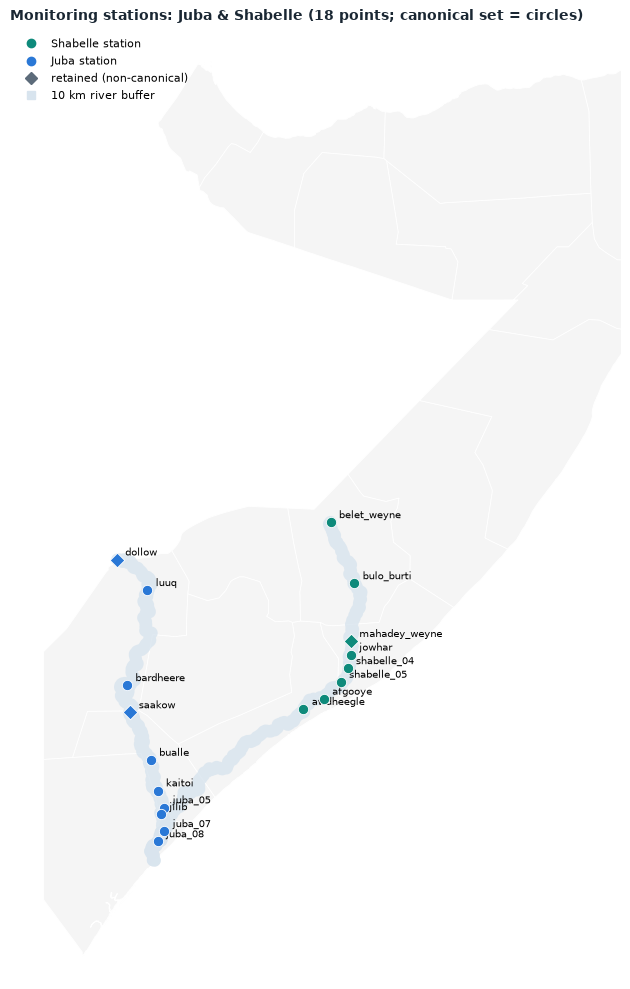

In [3]:
# admin boundaries + river buffers for context
adm1 = stratus.codab.load_codab_from_blob("som", admin_level=1)
_raw = stratus.load_blob_data("ds-aa-som-floods/processed/workflow/som_river_buffers.gpkg", stage="dev")
_tmp = os.path.join(tempfile.gettempdir(), "som_river_buffers.gpkg")
open(_tmp, "wb").write(_raw)
bufs = gpd.read_file(_tmp)

fig, ax = plt.subplots(figsize=(9, 10))
adm1.plot(ax=ax, color="#F5F5F5", edgecolor="white", linewidth=0.6)
bufs.plot(ax=ax, color="#D8E4EE", alpha=0.8)
RIVER_COLORS = {"shabelle": C_SHAB, "juba": C_JUBA}
for key, st in STATIONS.items():
    c = RIVER_COLORS[st.river]
    marker = "o" if st.canonical else "D"
    ax.scatter(st.lon, st.lat, color=c, marker=marker, s=55, zorder=5,
               edgecolors="white", linewidths=0.6)
    ax.annotate(key, (st.lon, st.lat), textcoords="offset points",
                xytext=(6, 3), fontsize=7)
handles = [
    plt.Line2D([], [], color=C_SHAB, marker="o", ls="", label="Shabelle station"),
    plt.Line2D([], [], color=C_JUBA, marker="o", ls="", label="Juba station"),
    plt.Line2D([], [], color=C_REF, marker="D", ls="", label="retained (non-canonical)"),
    plt.Line2D([], [], color="#D8E4EE", marker="s", ls="", label="10 km river buffer"),
]
ax.legend(handles=handles, loc="upper left", fontsize=8)
ax.set_xlim(40.5, 49.5); ax.set_ylim(-2, 12)
ax.set_title("Monitoring stations: Juba & Shabelle (18 points; canonical set = circles)", loc="left", fontsize=10)
ax.set_axis_off()
plt.tight_layout()


## 1. Rank correlation (daily Spearman, per source)

In [4]:
joint = {}   # (source, station) -> joined daily frame
rows = []
for src in SOURCES:
    g = dd[dd.source == src].set_index(["station", "date"])["discharge"]
    for st in gauged:
        if st not in g.index.get_level_values(0):
            continue
        j = pd.concat([g.loc[st], lv.loc[st]], axis=1, join="inner").dropna()
        j.columns = ["q", "level"]
        if len(j) < 1000:
            continue
        joint[(src, st)] = j
        rows.append({
            "station": st, "river": riv[st], "source": src, "n_days": len(j),
            "start": j.index.min().date(), "end": j.index.max().date(),
            "spearman": j["q"].corr(j["level"], method="spearman"),
        })
corr = pd.DataFrame(rows)
corr.pivot(index=["river", "station"], columns="source", values="spearman").round(3)


source                  geoglows  glofas_v5  google
river    station                                   
juba     bardheere         0.710      0.820   0.507
         bualle            0.822      0.855   0.686
         dollow            0.766      0.802   0.665
         kaitoi            0.733        NaN     NaN
         luuq              0.767      0.833   0.642
shabelle afgooye           0.778        NaN   0.728
         awdheegle         0.772        NaN   0.727
         belet_weyne       0.773      0.792   0.650
         bulo_burti        0.760      0.746   0.656
         jowhar            0.766      0.782   0.703
         mahadey_weyne     0.802        NaN   0.740

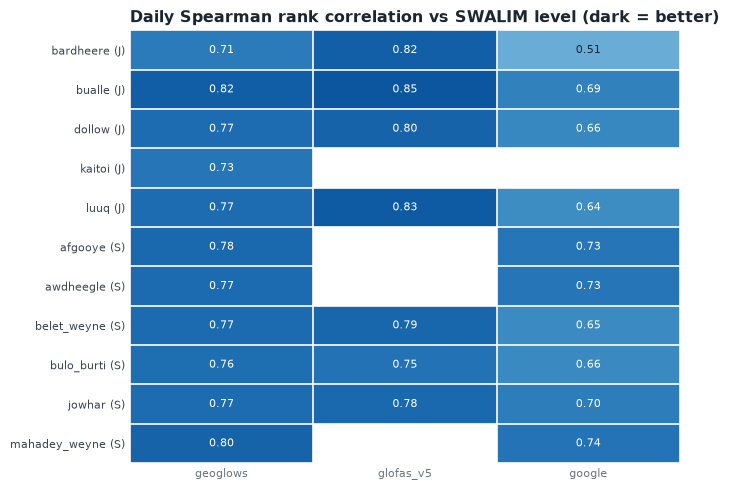

In [5]:
order = corr.drop_duplicates("station").sort_values(["river", "station"])
piv = corr.pivot(index="station", columns="source", values="spearman").loc[order.station]
row_labels = [f"{r.station} ({r.river[0].upper()})" for _, r in order.iterrows()]
fig, ax = plt.subplots(figsize=(7, 5))
vals = piv.values
ax.imshow(vals, vmin=0, vmax=1, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(piv.columns)))
ax.set_xticklabels(piv.columns, fontsize=8)
ax.set_yticks(range(len(piv.index)))
ax.set_yticklabels(row_labels, fontsize=8)
ax.set_xticks([x - 0.5 for x in range(len(piv.columns) + 1)], minor=True)
ax.set_yticks([y - 0.5 for y in range(len(piv.index) + 1)], minor=True)
ax.grid(which="minor", color="white", linewidth=1.2)
ax.tick_params(which="both", length=0)
for s in ax.spines.values():
    s.set_visible(False)

for (i, j), v in np.ndenumerate(vals):
    if not np.isnan(v):
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if v > 0.55 else INK)
ax.set_title("Daily Spearman rank correlation vs SWALIM level (dark = better)")
plt.tight_layout()


Rank correlation is not flood-event skill: section 3 shows the ordering
of sources changes once thresholds and events are involved.


## 2. Overlay: last 10 years of gauge record per station

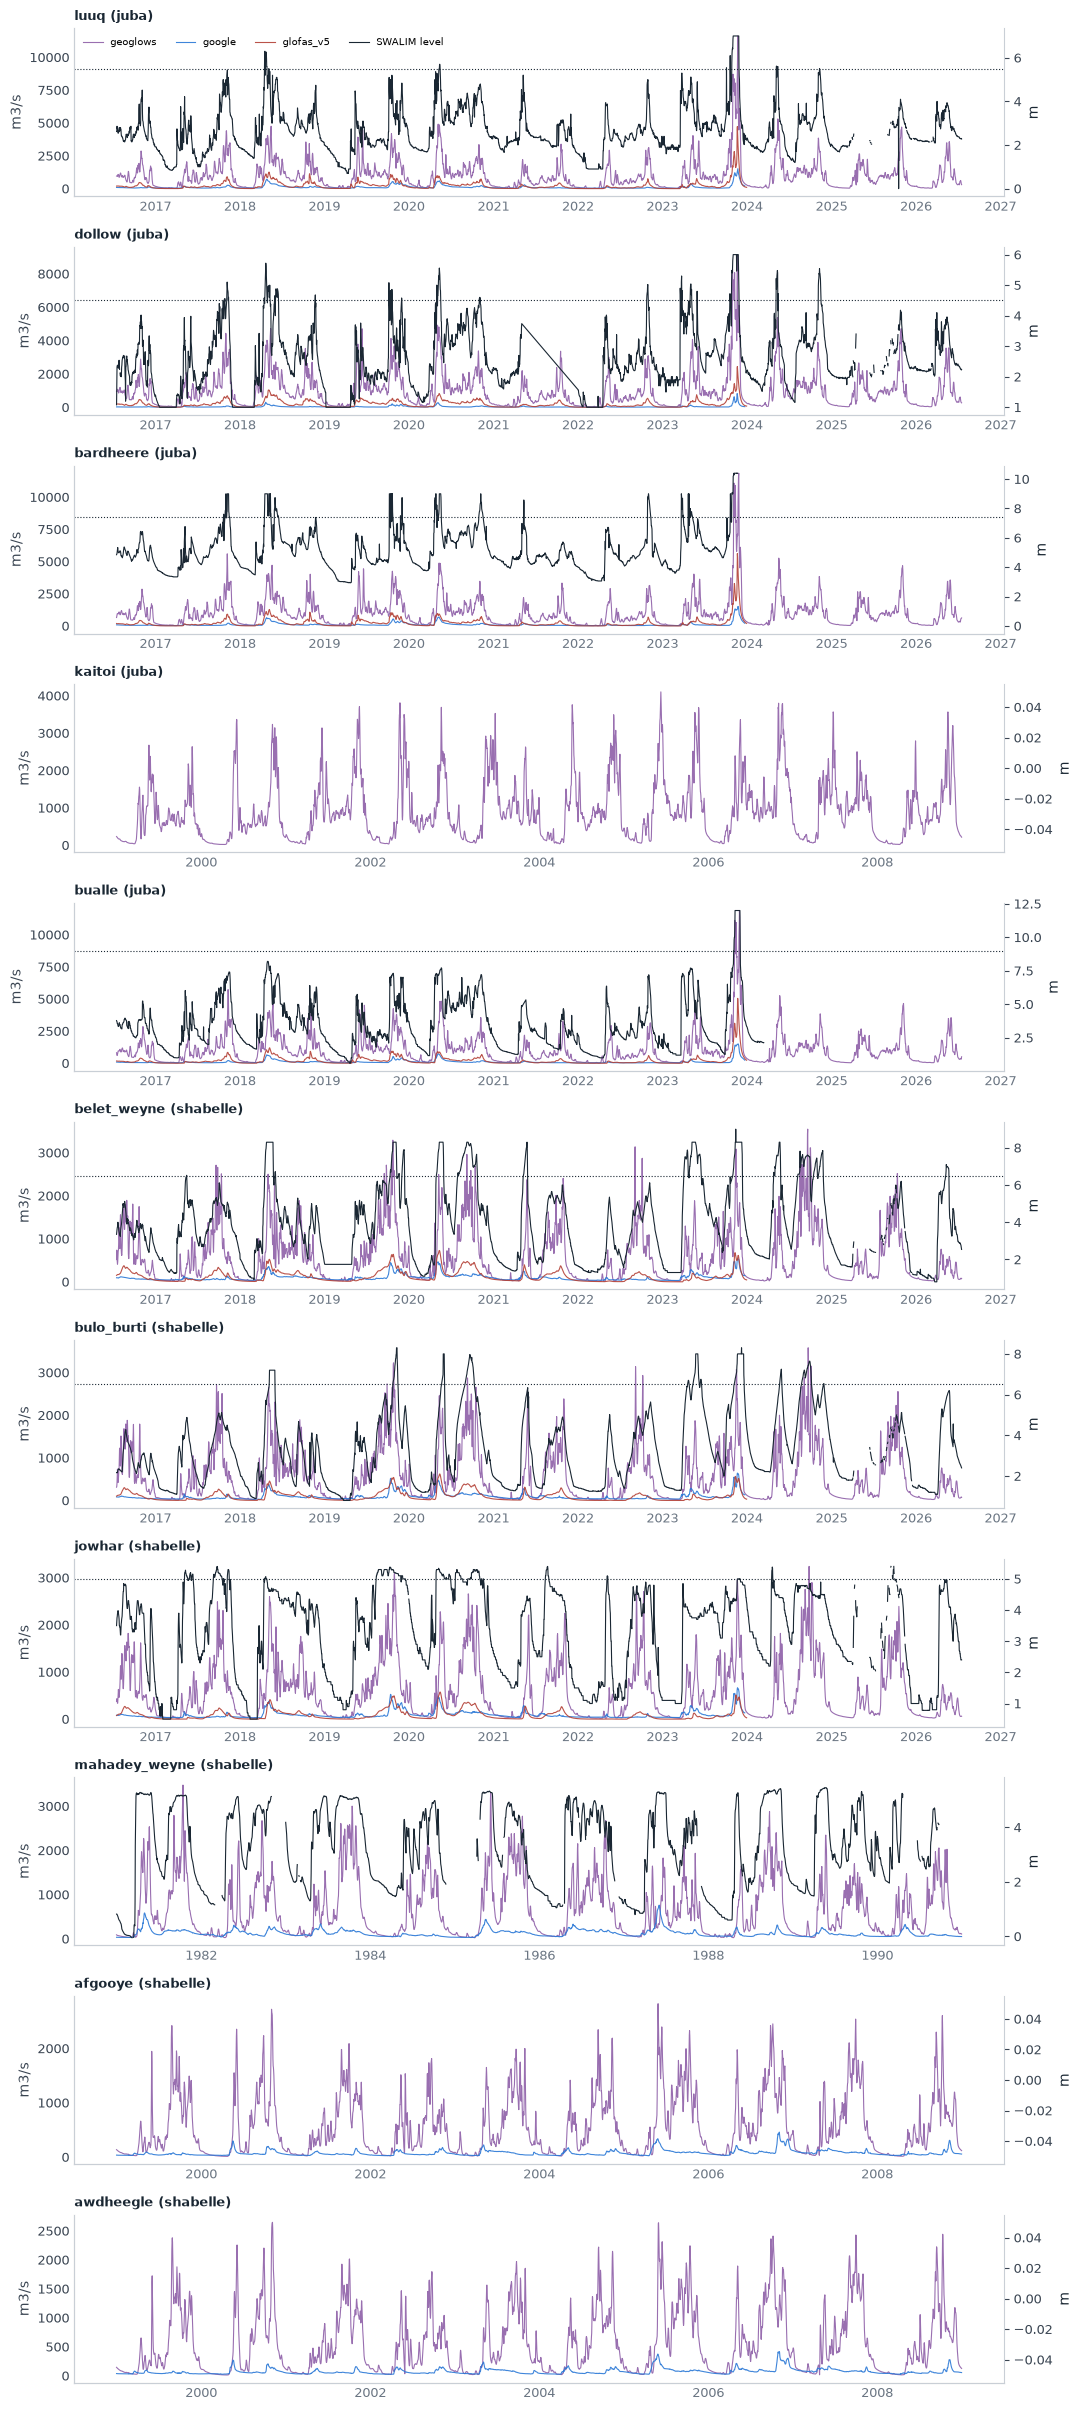

In [6]:
fig, axes = plt.subplots(len(gauged), 1, figsize=(11, 2.2 * len(gauged)))
for ax, st in zip(np.atleast_1d(axes), gauged):
    ax2 = ax.twinx()
    ax2.spines["right"].set_visible(True)
    end = lv.loc[st].index.max()
    start = end - pd.DateOffset(years=10)
    obs = lv.loc[st].loc[start:end]
    ax2.plot(obs.index, obs.values, lw=0.8, color=C_SWALIM, label="SWALIM level")
    thr = th.loc[st, "moderate_flood_risk"]
    if not np.isnan(thr):
        ax2.axhline(thr, color=C_SWALIM, ls=":", lw=0.8)
    for src in SOURCES:
        if (src, st) not in joint:
            continue
        g = dd[(dd.source == src) & (dd.station == st)].set_index("date")["discharge"].loc[start:end]
        ax.plot(g.index, g.values, lw=0.8, color=SOURCE_COLORS[src], label=src, alpha=0.9)
    ax.set_ylabel("m3/s")
    ax2.set_ylabel("m", color=C_SWALIM)
    ax.set_title(f"{st} ({riv[st]})", fontsize=9)
    style_ax(ax, grid=None)
    if st == gauged[0]:
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=7, ncol=4)
plt.tight_layout()


## 3. Flood-event agreement (RP3+ thresholds, common window)

Scored on the **common evaluation window 2002-01-01 to 2023-12-23**: both
models are present (GRRR ends Dec 2023) and SWALIM records are from the
modern re-established gauges (pre-1990 records may sit on different datums,
so applying today's thresholds to them is unsafe). Both sources therefore
face the **same observed events**.

Observed events = episodes of level >= threshold (gaps < 14 d merged; episode
counts are insensitive to this parameter: 21 vs 20 at Belet Weyne for 14 vs
30 d: and gauge gaps are only ~0.5-0.7% of days post-2002). Model events
likewise for discharge >= the source's RP3/RP4/RP5. Hit = overlap within
+/- 7 days. POD = hit fraction of observed events; FAR = fraction of model
events with no observed counterpart.

Mind the sample sizes: with ~10-30 observed events per station, a POD of
0.38 (8/21) carries a 95% CI of roughly 0.21-0.59, and a "FAR 0.00" on 8
model episodes is really "FAR <= ~0.3". Differences between sources on the
same events (e.g. 8/21 vs 2/21 hits at Belet Weyne) are meaningful; small
differences between adjacent RPs are not.

In [7]:
WINDOW = (pd.Timestamp("2002-01-01"), pd.Timestamp("2023-12-23"))


# post-2000 RP3 observed level per station (same estimator as notebook 01)
POST2000_RP3 = {}
for st in gauged:
    s = lv.loc[st]
    s2 = s[s.index.year >= 2000]
    am = s2.groupby(s2.index.year).max().dropna()
    POST2000_RP3[st] = weibull_level(am.values, 3)

rows = []
for src in SOURCES:
    grp = rp[rp.source == src].pivot(index="station", columns="return_period", values="discharge")
    for st in gauged:
        if (src, st) not in joint:
            continue
        full = dd[(dd.source == src) & (dd.station == st)].set_index("date")["discharge"]
        j = joint[(src, st)].loc[WINDOW[0]:WINDOW[1]]
        if len(j) < 1000:
            continue
        if st in grp.index:                      # published RPs
            q2, q5 = grp.loc[st, 2], grp.loc[st, 5]
            q_at = lambda T, a=q2, b=q5: a + (b - a) * (yT(T) - yT(2)) / (yT(5) - yT(2))
        else:                                     # derived (GloFAS)
            q_at = lambda T, s=full: gumbel_rp(s, T)
        # both benchmarks (user decision 2026-08-06): the official Moderate
        # level and the post-2000 RP3 refit from the gauge record
        benchmarks = {
            "moderate": th.loc[st, "moderate_flood_risk"],
            "rp3_post2000": POST2000_RP3.get(st, np.nan),
        }
        for obs_label, thr in benchmarks.items():
            if np.isnan(thr):
                continue
            obs = j["level"] >= thr
            if obs.sum() == 0:
                continue
            oe = episodes(obs)
            for T in [3, 4, 5]:
                me = episodes(j["q"] >= q_at(T))
                rows.append({
                    "station": st, "river": riv[st], "source": src,
                    "obs_threshold": obs_label, "rp": f"rp{T}",
                    "obs_episodes": len(oe), "model_episodes": len(me),
                    "POD": hits(oe, me) / len(oe),
                    "FAR": 1 - hits(me, oe) / len(me) if me else np.nan,
                })
ev = pd.DataFrame(rows)
ev.pivot(index=["river", "station", "obs_threshold"], columns=["source", "rp"], values=["POD", "FAR"]).round(2)


POD                                 \
source                             geoglows             google               
rp                                      rp3   rp4   rp5    rp3   rp4   rp5   
river    station     obs_threshold                                           
juba     bardheere   moderate          0.26  0.15  0.11   0.22  0.15  0.15   
                     rp3_post2000      0.25  0.25  0.25   0.50  0.25  0.25   
         bualle      moderate          1.00  1.00  1.00   1.00  1.00  1.00   
                     rp3_post2000      0.43  0.43  0.29   0.43  0.43  0.43   
         dollow      moderate          0.27  0.20  0.20   0.33  0.20  0.20   
                     rp3_post2000      0.67  0.67  0.67   1.00  1.00  1.00   
         luuq        moderate          0.33  0.25  0.25   0.42  0.33  0.25   
                     rp3_post2000      0.22  0.11  0.11   0.44  0.33  0.22   
shabelle belet_weyne moderate          0.10  0.05  0.05   0.38  0.33  0.19   
                     rp3_post2000      0.10  0.10  0.10   0.50  0.50  0.30   
         bulo_burti  moderate          0.07  0.07  0.07   0.33  0.20  0.20   
                     rp3_post2000      0.11  0.11  0.11   0.44  0.22  0.22   
         jowhar      moderate          0.03  0.00  0.00   0.20  0.11  0.09   
                     rp3_post2000      0.10  0.00  0.00   0.20  0.10  0.10   

                                                              FAR              \
source                             glofas_v5             geoglows               
rp                                       rp3   rp4   rp5      rp3   rp4   rp5   
river    station     obs_threshold                                              
juba     bardheere   moderate           0.15  0.04  0.04     0.11  0.20  0.00   
                     rp3_post2000       0.50  0.25  0.25     0.89  0.80  0.67   
         bualle      moderate           1.00  1.00  1.00     0.89  0.80  0.67   
                     rp3_post2000       0.29  0.14  0.14     0.67  0.40  0.33   
         dollow      moderate           0.27  0.13  0.13     0.33  0.40  0.40   
                     rp3_post2000       1.00  0.33  0.33     0.67  0.60  0.60   
         luuq        moderate           0.25  0.08  0.08     0.64  0.50  0.00   
                     rp3_post2000       0.22  0.11  0.11     0.82  0.83  0.67   
shabelle belet_weyne moderate           0.52  0.43  0.33     0.00  0.00  0.00   
                     rp3_post2000       0.70  0.60  0.60     0.50  0.00  0.00   
         bulo_burti  moderate           0.60  0.53  0.47     0.50  0.00  0.00   
                     rp3_post2000       0.89  0.56  0.56     0.50  0.00  0.00   
         jowhar      moderate           0.23  0.14  0.11     0.67  1.00  1.00   
                     rp3_post2000       0.20  0.20  0.20     0.67  1.00  1.00   

                                                                             
source                             google             glofas_v5              
rp                                    rp3   rp4   rp5       rp3   rp4   rp5  
river    station     obs_threshold                                           
juba     bardheere   moderate        0.14  0.20  0.20      0.00  0.00  0.00  
                     rp3_post2000    0.71  0.80  0.80      0.50  0.00  0.00  
         bualle      moderate        0.83  0.80  0.75      0.75  0.00  0.00  
                     rp3_post2000    0.50  0.40  0.25      0.50  0.00  0.00  
         dollow      moderate        0.00  0.00  0.00      0.00  0.00  0.00  
                     rp3_post2000    0.40  0.00  0.00      0.25  0.50  0.50  
         luuq        moderate        0.38  0.43  0.40      0.00  0.00  0.00  
                     rp3_post2000    0.50  0.57  0.60      0.33  0.00  0.00  
shabelle belet_weyne moderate        0.00  0.00  0.20      0.08  0.00  0.00  
                     rp3_post2000    0.38  0.29  0.40      0.42  0.33  0.14  
         bulo_burti  moderate        0.38  0.40  0.25      0.25  0.11  0.12  
      

### Scorecard at a glance

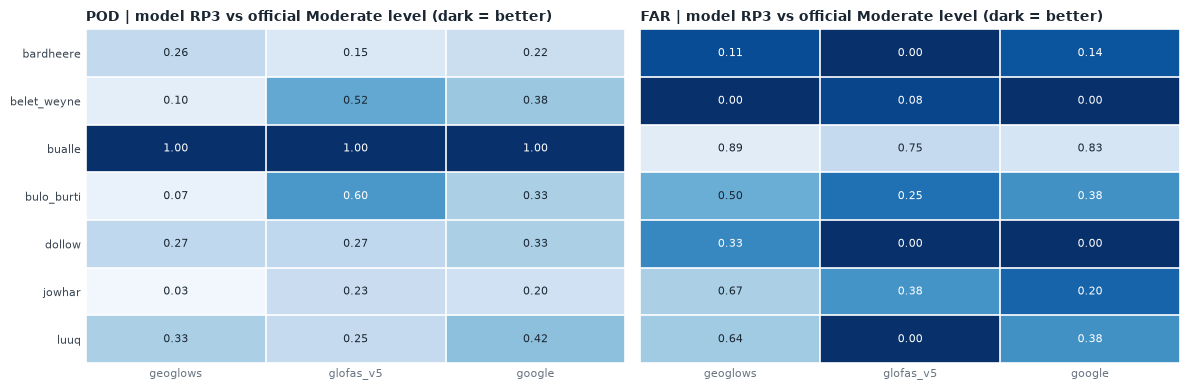

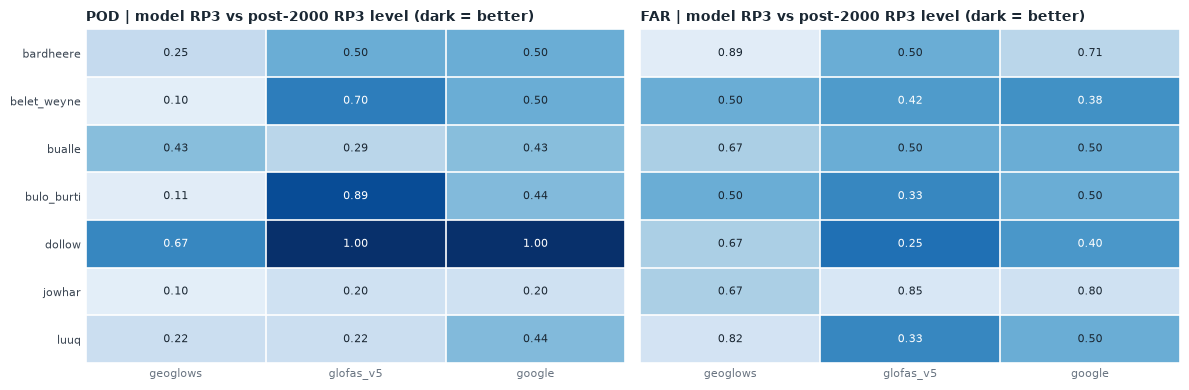

In [8]:
for bench, blabel in [
    ("moderate", "official Moderate level"),
    ("rp3_post2000", "post-2000 RP3 level"),
]:
    best = ev[(ev.rp == "rp3") & (ev.obs_threshold == bench)]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, metric in zip(axes, ["POD", "FAR"]):
        piv = best.pivot_table(index="station", columns="source", values=metric)
        vals = piv.values
        shade = 1 - vals if metric == "FAR" else vals  # dark = good either way
        ax.imshow(shade, vmin=0, vmax=1, cmap="Blues", aspect="auto")
        ax.set_xticks(range(len(piv.columns)))
        ax.set_xticklabels(piv.columns, fontsize=8)
        ax.set_yticks(range(len(piv.index)))
        ax.set_yticklabels(piv.index, fontsize=8)
        ax.set_xticks([x - 0.5 for x in range(len(piv.columns) + 1)], minor=True)
        ax.set_yticks([y - 0.5 for y in range(len(piv.index) + 1)], minor=True)
        ax.grid(which="minor", color="white", linewidth=1.2)
        ax.tick_params(which="both", length=0)
        for s in ax.spines.values():
            s.set_visible(False)
        for (i, j), v in np.ndenumerate(vals):
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                        color="white" if shade[i, j] > 0.55 else INK)
        ax.set_title(
            f"{metric} | model RP3 vs {blabel} (dark = better)", fontsize=10
        )
    plt.tight_layout()
    plt.show()


## 3b. Best RP3+ operating point per station-source

Ranked by POD x (1 - FAR). **Caveat:** picking the best of 6 threshold/benchmark
combos per station-source post-hoc flatters the scores (selection effect) :
treat these as candidates to validate on the forecast/reforecast data, not as
final skill estimates.

In [9]:
ev["CSI_proxy"] = ev["POD"] * (1 - ev["FAR"])  # crude single-number ranking
best = ev.loc[ev.groupby(["station", "source"])["CSI_proxy"].idxmax()]
best[["river", "station", "source", "obs_threshold", "rp", "obs_episodes",
      "model_episodes", "POD", "FAR"]].sort_values(["river", "station", "source"]).round(2)


,river,station,source,obs_threshold,rp,obs_episodes,model_episodes,POD,FAR
12,juba,bardheere,geoglows,moderate,rp3,27,9,0.26,0.11
99,juba,bardheere,glofas_v5,rp3_post2000,rp3,4,4,0.50,0.50
54,juba,bardheere,google,moderate,rp3,27,7,0.22,0.14
20,juba,bualle,geoglows,moderate,rp5,1,3,1.00,0.67
103,juba,bualle,glofas_v5,moderate,rp4,1,1,1.00,0.00
65,juba,bualle,google,rp3_post2000,rp5,7,4,0.43,0.25
10,juba,dollow,geoglows,rp3_post2000,rp4,3,5,0.67,0.60
93,juba,dollow,glofas_v5,rp3_post2000,rp3,3,4,1.00,0.25
52,juba,dollow,google,rp3_post2000,rp4,3,3,1.00,0.00
2,juba,luuq,geoglows,moderate,rp5,12,3,0.25,0.00


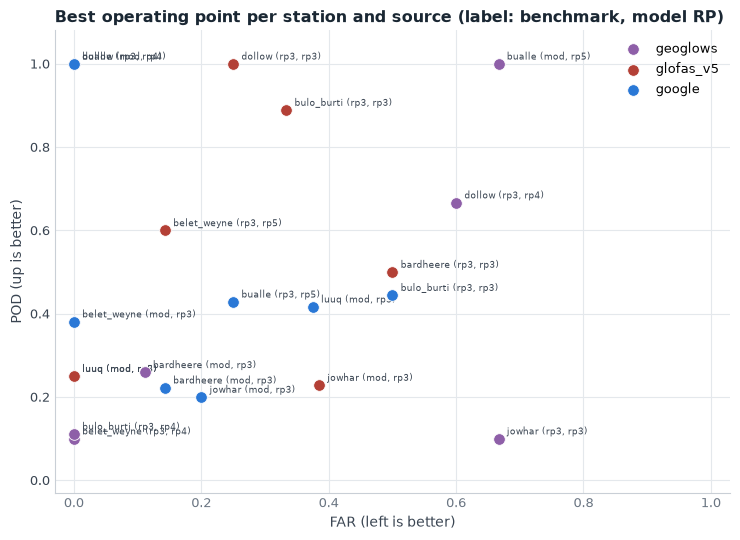

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for srcname, g in best.groupby("source"):
    ax.scatter(g["FAR"], g["POD"], color=SOURCE_COLORS[srcname], s=70,
               edgecolors="white", linewidths=0.6, label=srcname, zorder=5)
for _, r in best.iterrows():
    ax.annotate(f"{r.station} ({r.obs_threshold[:3]}, {r.rp})", (r.FAR, r.POD),
                textcoords="offset points", xytext=(6, 3), fontsize=6.5, color=BODY)
ax.set_xlabel("FAR (left is better)")
ax.set_ylabel("POD (up is better)")
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.03, 1.08)
ax.set_title("Best operating point per station and source (label: benchmark, model RP)")
ax.legend()
style_ax(ax, grid="both")
plt.tight_layout()


## 4. Magnitude bias vs real observed discharge

The event scores above use each model's own return periods, which hides
magnitude bias. Four stations have real observed discharge (scraped from the
SNRFA station pages during the EF5 work; note it is a deterministic rating
transform of level and caps at bank-full). Ratios >1 mean the model runs high.

In [11]:
OBS = {"belet_weyne": "beletweyne", "bulo_burti": "buloburte", "luuq": "luuq", "bardheere": "bardheere"}
rows = []
obs_q = {}
for key, slug in OBS.items():
    raw = _json.loads(stratus.load_blob_data(
        f"ds-aa-som-floods/raw/ef5/analysis/{slug}_real_discharge.json", stage="dev"))
    o = pd.Series(raw, dtype=float)
    o.index = pd.to_datetime(o.index)
    obs_q[key] = o.sort_index().dropna()
for key in OBS:
    for src in SOURCES:
        m = dd[(dd.source == src) & (dd.station == key)].set_index("date")["discharge"]
        j = pd.concat([m, obs_q[key]], axis=1, join="inner").dropna()
        j.columns = ["mod", "obs"]
        j = j[j["obs"] > 0]
        if len(j) < 1000:
            continue
        am = j.resample("YE").max().dropna()
        rows.append({
            "station": key, "source": src, "n_days": len(j),
            "median_ratio": j["mod"].median() / j["obs"].median(),
            "q95_ratio": j["mod"].quantile(.95) / j["obs"].quantile(.95),
            "annual_max_ratio": (am["mod"] / am["obs"]).median(),
            "spearman_vs_Q": j["mod"].corr(j["obs"], method="spearman"),
        })
bias = pd.DataFrame(rows).set_index(["station", "source"])
bias.round(2)


n_days  median_ratio  q95_ratio  annual_max_ratio  \
station     source                                                         
belet_weyne geoglows    17090          6.29       6.35              9.26   
            google      11084          1.24       0.76              0.82   
            glofas_v5    7293          0.96       1.02              1.08   
bulo_burti  geoglows    13213          7.34       8.48             11.44   
            google       9163          1.33       0.96              1.04   
            glofas_v5    7143          0.81       1.26              1.22   
luuq        geoglows    19417          5.71       4.83              4.59   
            google      11195          0.58       0.53              0.44   
            glofas_v5    8053          0.99       0.98              0.86   
bardheere   geoglows    13742          0.94       1.44              1.70   
            google      11168          0.07       0.14              0.15   
            glofas_v5    8042          0.13       0.30              0.31   

                       spearman_vs_Q  
station     source                    
belet_weyne geoglows            0.75  
            google              0.62  
            glofas_v5           0.77  
bulo_burti  geoglows            0.76  
            google              0.66  
            glofas_v5           0.76  
luuq        geoglows            0.78  
            google              0.64  
            glofas_v5           0.83  
bardheere   geoglows            0.71  
            google              0.51  
            glofas_v5           0.82

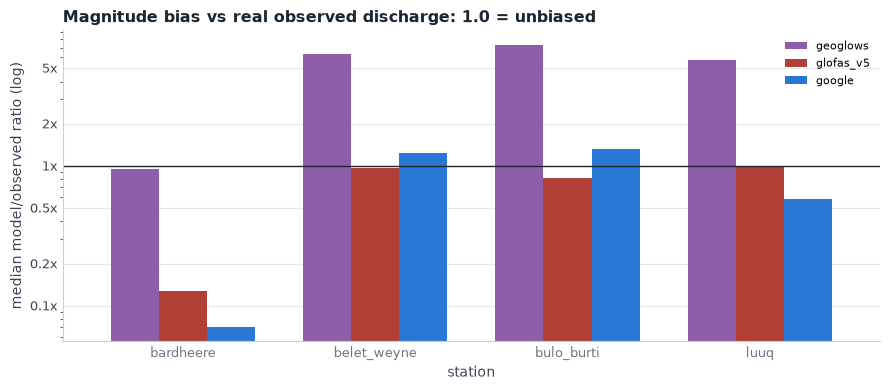

In [12]:
piv = bias.reset_index().pivot(index="station", columns="source", values="median_ratio")
fig, ax = plt.subplots(figsize=(9, 4))
piv.plot.bar(ax=ax, width=0.75, color=[SOURCE_COLORS[c] for c in piv.columns])
ax.axhline(1.0, color=INK, lw=1)
ax.set_yscale("log")
ticks = [0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10]
ax.yaxis.set_major_locator(FixedLocator(ticks))
ax.yaxis.set_major_formatter(lambda v, _: f"{v:g}x")
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set_ylabel("median model/observed ratio (log)")
ax.set_title("Magnitude bias vs real observed discharge: 1.0 = unbiased")
ax.legend(fontsize=8)
plt.xticks(rotation=0)
style_ax(ax, grid="y")
plt.tight_layout()


**Should we bias correct? Yes: before any absolute-discharge use.**

- **GEOGloWS runs 5-12x high** at Belet Weyne, Bulo Burti and Luuq (annual
  maxima up to ~11x), yet is ~unbiased at Bardheere. Its absolute discharge
  (and any threshold imported from a rating curve) is unusable uncorrected;
  RP-relative or quantile-mapped use only. Its RP3+ under-firing is therefore
  a *variability/shape* mis-calibration (its floods are mild relative to its
  own inflated climatology), not explained by mean bias.
- **GloFAS v5 is near-unbiased at three of the four stations** (Belet Weyne
  0.96x, Luuq 0.99x, Bulo Burti 0.81x median; annual maxima 0.9-1.2x) and has
  the best rank correlation against real discharge everywhere (rho
  0.76-0.83). The v4 wet bias (4-6x on these stations, notebook 04) is gone.
- **Google GRRR is near-unbiased on the middle Shabelle** (Belet Weyne 1.2x,
  Bulo Burti 1.3x median) but runs 0.6x at Luuq.
- **Bardheere breaks the downscaled models:** GRRR 0.07x and GloFAS v5 0.13x
  are order-of-magnitude failures at that reach; only GEOGloWS (0.94x) tracks
  its magnitude. Do not use GRRR or v5 absolute discharge there.
- Practical rule: keep triggers on each model's own return periods (an
  implicit frequency bias correction), and where absolute magnitudes are
  needed, quantile-map model output onto the observed discharge distribution
  per station.


## Takeaways (RP3+ constraint, common 2002-2023 window, GloFAS = v5)

Benchmarks: both the **official Moderate level** and the **post-2000 RP3**
are scored (two scorecards in section 3). Headline numbers below are model
RP3 vs Moderate; the RP3-benchmark scorecard reads higher-POD/higher-FAR
because RP3 events are more frequent at most stations (e.g. Belet Weyne v5:
0.70/0.42 vs 0.52/0.08), with the ranking unchanged.

**GloFAS v5 is the strongest source on the Shabelle.**

- **Belet Weyne: v5 POD 0.52 / FAR 0.08**; GRRR 0.38/0.00; GEOGloWS 0.10.
- **Bulo Burti: v5 POD 0.60 / FAR 0.25**; GRRR 0.33/0.38; GEOGloWS 0.07/0.50.
- **Jowhar still defeats everything** (POD <= 0.23): its off-take and marsh
  hydraulics decouple local level from upstream discharge. Keep a
  level-based trigger there.

**On the Juba, v5 and GRRR split the honors:**

- **Luuq: GRRR has the POD edge (0.42 at FAR 0.38); v5 trades down to 0.25
  at FAR 0.00.**
- **Bardheere: GEOGloWS 0.26/0.11 has the best hit rate; v5 is 0.15/0.00.**
  (Raw magnitudes: only GEOGloWS is usable there, section 4.)
- **Bualle is degenerate at this benchmark**: its official Moderate (9.0 m)
  was reached only once (2023), so every source scores POD 1.00 on a single
  event at FAR 0.75-0.89. Read nothing into that row.
- **Dollow: v5 and GRRR tie on POD (0.27-0.33) with FAR 0.00.**

**Magnitude bias (section 4): v5 largely fixes it.** Median-flow ratios vs
real observed discharge:

| station | GEOGloWS | GloFAS v5 | GRRR |
|---|---|---|---|
| Belet Weyne | 6.3x | **0.96x** | 1.2x |
| Bulo Burti | 7.3x | **0.81x** | 1.3x |
| Luuq | 5.7x | **0.99x** | 0.6x |
| Bardheere | **0.94x** | 0.13x | 0.07x |

GEOGloWS still runs several times high on the Shabelle; v5 and GRRR are close
to unbiased there but both collapse at Bardheere. Note the observed rating
caps at bank-full, so high-quantile ratios are *upper* bounds on model
underestimation. Practical rule: trigger on each model's own return periods
(an implicit frequency correction), and quantile-map per station wherever
absolute magnitudes are needed.

**Sampling caution.** Moderate episodes number roughly 10-30 per station in
the window, so a POD of 0.52 (11/21) has a 95% CI of about 0.32-0.71, and
"FAR 0.00" on a handful of model episodes means "FAR <= ~0.3". Differences
between sources on the same events are meaningful; small differences between
adjacent RPs are not. v5's RPs are Gumbel-fitted to its own reanalysis
(in-sample: it publishes none), so treat its FAR as optimistic.

**The v5 catch: no reforecast archive exists.** All of the above is
observed-rainfall-driven reanalysis: a skill ceiling, not trigger skill. The
operational question is skill at 1-7 day lead, and reforecasts exist only for
**v4** (notebook 03). So v5's reanalysis skill can only be exercised
operationally by (a) running live v5 forecasts against v5-fitted RPs
prospectively, or (b) assuming v4-lead skill transfers, which notebook 04's
bias gap argues against. GRRR reforecast (2016-2023, leads 0-7 d) is already
in the reforecast table; GEOGloWS publishes no multi-year reforecast archive.

Review notes: scored on a common window so all sources face the same events;
processed tables checked for duplicates/NaNs (none); episode counts shown
insensitive to the gap parameter; GloFAS timestamps shifted -1 day (its
24-hour means are stamped at period end) and extracted at the model channel
cell.
